In [ ]:
# prefix node reward assignment

let me think               A*=+0.58  ΣA=-0.00 (mean -0.00)  cnt=4  correct=3
  step                       A*=+0.58  ΣA=-0.58 (mean -0.19)  cnt=3  correct=2
    A then 42                  A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1
    B then                     A*=+0.58  ΣA=-1.15 (mean -0.58)  cnt=2  correct=1
      17                         A*=-1.73  ΣA=-1.73 (mean -1.73)  cnt=1  correct=0
      17, but wait it should be 42 A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1
  harder C then 9            A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1


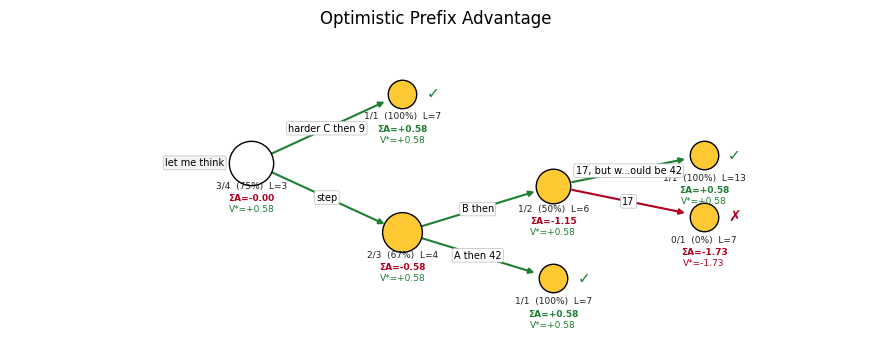

In [2]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("/Users/fangyuanyu/Implementation/arl")))
import src.prefix_trie as pt
importlib.reload(pt)   # pick up changes without restarting the kernel

# ---------------------------------------------------------------------------
# Convention (per request):
#   (1) REWARD is the hard-coded scalar per rollout. Here it's the plain
#       correctness reward, so every CORRECT rollout shares reward = 1.0.
#   (2) ADVANTAGE is computed EXACTLY, GRPO-style, over the group:
#         a_i = (r_i - mean(r)) / (std(r) + eps)
#   (3) V*(node) = max ADVANTAGE over rollouts through the node (optimistic
#       backup over the per-trajectory advantage).
# ---------------------------------------------------------------------------
EPS = 1e-8

rollouts = [
    ("let me think step A then 42".split(),   True),   # correct
    ("let me think step B then 17".split(),   False),  # wrong
    ("let me think step B then 17, but wait it should be 42".split(),   True),  # correct
    ("let me think harder C  then 9".split(), True),  # wrong
]
correct = np.array([c for _, c in rollouts], dtype=float)
reward  = correct.copy()                      # hard-coded reward = correctness

# (1)+(2): exact GRPO advantage over the group.
mean_r = reward.mean()
std_r  = reward.std()                          # population std (ddof=0)
advantage = (reward - mean_r) / (std_r + EPS)  # per-trajectory advantage

tbl = pd.DataFrame({
    "rollout":   [" ".join(t) for t, _ in rollouts],
    "correct":   correct.astype(bool),
    "reward":    reward,
    "advantage": advantage.round(4),
})

# (3): build the trie with the advantage as the per-rollout value.
# `build_trie_with_correctness` feeds `advantage` to BOTH ΣA and V* (= max adv).
rows = [(toks, bool(c), float(a))
        for (toks, c), a in zip(rollouts, advantage)]
trie = pt.build_trie_with_correctness(rows)
tree = pt._collapse(trie.root)

def show(node, depth=0):
    seg = " ".join(node["tokens"]) or "(root)"
    adv_mean = node["adv_sum"] / node["adv_n"] if node["adv_n"] else float("nan")
    print(f"{'  '*depth}{seg:<26s} A*={node['v_star']:+.2f}  "
          f"ΣA={node['adv_sum']:+.2f} (mean {adv_mean:+.2f})  "
          f"cnt={node['count']}  correct={node['count_correct']}")
    for ch in node["children"].values():
        show(ch, depth + 1)

# print("Optimistic Prefix Advantage")
show(tree)


fig, ax = plt.subplots(figsize=(11, 4))
pt.draw_compressed_trie(ax, trie)
ax.set_title("Optimistic Prefix Advantage")
plt.show()


In [3]:
# (1) Tree-based sampling with a real model (Qwen3-0.6B, run locally).
#     Same logic as the toy cell above: each current leaf spawns `branch`
#     continuations of `block_size` tokens; identical continuations collapse,
#     so a leaf forks into 1..branch children.
#     NOTE: `block_size` is the per-step extension length. Set it equal to the
#     vLLM KV `block_size` (commonly 16) so prefix-cache reuse lands on block
#     boundaries — same number on purpose.
#     TERMINATION: a continuation that emits <eos> is truncated at the first
#     <eos> and its leaf is marked `done`; done leaves are carried forward as-is
#     (never re-expanded), so we don't dumbly generate past end-of-sequence.
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen3-0.6B"
DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
gen_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=(torch.float32 if DEVICE == "cpu" else torch.float16),
).to(DEVICE).eval()
EOS_ID = tokenizer.eos_token_id
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else EOS_ID
print(f"loaded {MODEL_NAME} on {DEVICE}")


@torch.no_grad()
def _continue(prefix_ids, block_size, n_samples, temperature):
    """Sample `n_samples` continuations of up to `block_size` tokens from a 1-D
    prefix. Returns a list of (cont_tokens, done) pairs; a continuation that
    hits <eos> is truncated to include that <eos> and flagged done."""
    batch = prefix_ids.unsqueeze(0).repeat(n_samples, 1).to(DEVICE)
    out = gen_model.generate(
        batch, max_new_tokens=block_size, do_sample=True,
        temperature=temperature, pad_token_id=PAD_ID, eos_token_id=EOS_ID,
    )
    new = out[:, prefix_ids.shape[0]:]                 # (n_samples, <=block_size)
    results = []
    for row in new.tolist():
        if EOS_ID in row:                              # truncate at first <eos>
            row = row[: row.index(EOS_ID) + 1]
            done = True
        else:
            done = False
        results.append((row, done))
    return results


def tree_sample(prompt, n_steps=3, block_size=8, branch=2,
                temperature=1.0, seed=0):
    """Breadth-first tree sampling. Returns (prompt_ids, steps) where
    steps[k] is the list of leaf continuations (token-id lists, EXCLUDING the
    prompt) present after sampling step k. Leaves that have emitted <eos> are
    carried forward unchanged rather than re-expanded."""
    torch.manual_seed(seed)
    prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids[0]
    leaves = [([], False)]                             # (continuation_so_far, done)
    steps = {}
    for step in range(n_steps):
        nxt, seen = [], set()
        for leaf, done in leaves:
            if done:                                   # terminated: carry forward, don't regenerate
                key = tuple(leaf)
                if key not in seen:
                    seen.add(key); nxt.append((leaf, True))
                continue
            prefix = torch.cat([prompt_ids, torch.tensor(leaf, dtype=torch.long)])
            for cont, cont_done in _continue(prefix, block_size, branch, temperature):
                child = leaf + cont
                key = tuple(child)
                if key not in seen:                    # dedup identical continuations
                    seen.add(key); nxt.append((child, cont_done))
        leaves = nxt
        steps[step] = [list(l) for l, _ in leaves]
    return prompt_ids, steps


loaded Qwen/Qwen3-0.6B on mps


In [26]:
# (2) Assign GRPO scalar advantage + OPA per-token advantage on the FINAL
#     leaves (the complete rollouts). Earlier steps are structural only.
#
#     TASK = Game of 24 (real prompt + real reward), reward design aligned with
#     GSM8K (script/grpo_gsm8k.py): trajectory reward = format + correctness,
#     summed, then GRPO-baselined into advantages.
#       - format_reward      : 0.2 if a '#### <expr>' answer line is present.
#       - correctness_reward : 1.0 if the expression uses each number once and
#                              evaluates to TARGET (src.game24utils.verify_24).
import src.tree_trainer as tt
import src.game24utils as g24
importlib.reload(tt)
importlib.reload(g24)

# --- DEBUG variant: 2-number "Game of 10" for studying reward assignment -----
# g24 now threads an optional `target` (default 24) through verify_24 /
# correctness_reward, so we just pass target=TARGET — no monkeypatching, and
# we build a custom user prompt (bypassing to_chat's "Make 24"/4-number text).
# Pick numbers with a non-degenerate group: 4+6=10 and 4*6=24≠10, so some
# leaves land on 10 and some don't.
TARGET  = 10
NUMBERS = [3, 7]            # solvable: 4 + 6 = 10  (try [2, 5] -> 2*5, [12, 2] -> 12-2)
n_steps = 3
n_branch = 2
max_new_tokens=64
block_size = max_new_tokens // n_steps

_num_str = ",".join(map(str, NUMBERS))
_user = (f"Given numbers: {_num_str}. Make {TARGET}. "
         "After thinking, give your final expression on the last line after '#### '.")
PROMPT = tokenizer.apply_chat_template(
    [{"role": "user", "content": _user}],
    tokenize=False, add_generation_prompt=True, enable_thinking=False,
)
prompt_ids, steps = tree_sample(PROMPT, n_steps=n_steps, block_size=block_size, branch=n_branch,
                                temperature=1.0, seed=0)

final = steps[max(steps)]                              # complete rollouts (token-id lists)
texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in final]

# --- reward: Game-of-N, GSM8K-aligned (format + correctness) -----------------
nums_batch = [NUMBERS] * len(texts)
fmt  = np.array(g24.format_reward(texts), dtype=float)                          # 0.2 if '#### <expr>'
corr = np.array(g24.correctness_reward(texts, nums_batch, target=TARGET), dtype=float)  # 1.0 if == TARGET
reward = fmt + corr                                                             # trajectory reward

# GRPO group advantage  a_i = (r_i - mean) / (std + eps).
adv = (reward - reward.mean()) / (reward.std() + EPS)

# OPA per-token A* over the group, keyed on the REAL token ids (exact).
per_token, opa_trie = tt.optimistic_prefix_advantages(
    final, adv.tolist(), return_trie=True,
)

print(f"Game of {TARGET} | numbers={NUMBERS}  (solved={int(corr.sum())}/{len(corr)})\n")
# add a line to report unique rollouts / total rollouts
_n_unique = len({tuple(ids) for ids in final}) # total = n_step x branch
_n_total = n_branch**n_steps

print(f"unique rollouts: {_n_unique}/{_n_total}  ({_n_unique / _n_total:.0%} distinct)\n")
for t, f, c, a in zip(texts, fmt, corr, adv):
    expr = g24.extract_expr(t)
    print(f"fmt={f:.1f} corr={c:.1f} a={a:+.2f} | expr={expr!r:<22} | {t!r}")
print(f"\nshared-prefix token fraction (final trie): "
      f"{opa_trie.shared_prefix_token_fraction:.1%}")
print(f"breakdown: {opa_trie.token_node_breakdown()}")

Game of 10 | numbers=[3, 7]  (solved=3/8)

unique rollouts: 8/8  (100% distinct)

fmt=0.0 corr=0.0 a=-0.91 | expr=''                     | 'To make **10** using the numbers **3 and 7**, we can use the **addition** operation:\n\n$$\n7 + 3 = 10\n$$\n\nSo the expression is:\n\n$$\n\\boxed{7 + 3 = 10}\n$$'
fmt=0.2 corr=0.0 a=-0.55 | expr=''                     | 'To make **10** using the numbers **3 and 7**, we can use the **addition** operation:\n\n$$\n7 + 3 = 10\n$$\n\nSo the expression is:\n\n$$\n\\boxed{7 + 3 = 10}\n$$\n\n#### ✅ Final'
fmt=0.2 corr=0.0 a=-0.55 | expr=''                     | "To make **10** using the numbers **3 and 7**, we can use the **addition** operation. Here's one way:\n\n- $ 3 + 7 = 10 $\n\n### Final answer:\n\n**3 + 7 = 10**\n\n#### **####**"
fmt=0.2 corr=1.0 a=+1.28 | expr='3 + 7'                | "To make **10** using the numbers **3 and 7**, we can use the **addition** operation. Here's one way:\n\n- $ 3 + 7 = 10 $\n\nSo the final expression is:\n\n**#### 3 

In [ ]:
# Naive tree-sampling can't nail the diversity problem, conditioning on on-policy prefix, we study the "prefix trie" MCTS gadget

# (1). carry out several rollouts batch on a single query, and update its "global" prefix trie & visualize it

round 0: solved=2/8  distinct=8/8 intended
round 1: solved=3/8  distinct=8/8 intended
round 2: solved=2/8  distinct=8/8 intended
round 3: solved=5/8  distinct=8/8 intended


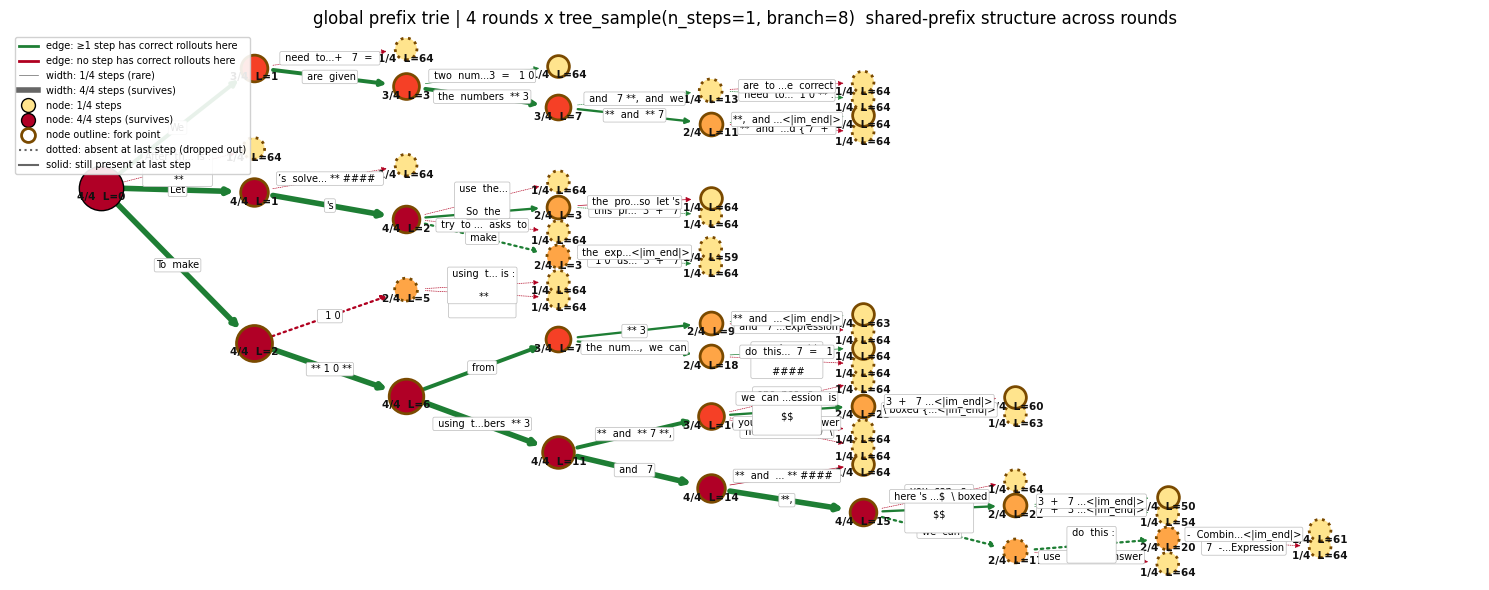

In [27]:
# (gadget-1) "Global" prefix trie pooled from several rollout batches on one query.
#     Reuses tree_sample, so the SAME cell explores the whole sampling-config
#     space: set N_STEPS=1 for flat batches, or N_STEPS>1 / BRANCH>1 to fork and
#     watch the prefix bottleneck collapse diversity. Each round is one tree_sample
#     call; all rounds pool into one persistent pt.MultiStepTrie keyed by round:
#       - node face  -> in how many of the R rounds the prefix recurs (survival)
#       - edge width -> same survival, thin=1 round, thick=all rounds
#       - L=         -> accumulated prefix length (tokens) from root
#     NOTE: tree_sample dedups identical continuations, so the per-round group is
#     the DISTINCT leaves; total intended samples = BRANCH**N_STEPS.

R          = 4      # number of rollout batches ("rounds" / global steps)
N_STEPS    = 1      # tree-sampling depth (1 = flat batch; >1 = forking)
BRANCH     = 8      # continuations per leaf per step
BLOCK_SIZE = 64 // N_STEPS   # per-step extension; total new tokens ~= 64
TEMP       = 1.0

decode_tok = lambda ids: [tokenizer.decode([i]) for i in ids]

global_trie = pt.MultiStepTrie()
for r in range(R):
    _, steps = tree_sample(PROMPT, n_steps=N_STEPS, block_size=BLOCK_SIZE,
                           branch=BRANCH, temperature=TEMP, seed=r)
    final  = steps[max(steps)]                                   # distinct leaf rollouts
    txts   = [tokenizer.decode(ids, skip_special_tokens=True) for ids in final]
    nums   = [NUMBERS] * len(txts)
    fmt    = np.array(g24.format_reward(txts), dtype=float)
    corr   = np.array(g24.correctness_reward(txts, nums, target=TARGET), dtype=float)
    reward = fmt + corr
    adv    = (reward - reward.mean()) / (reward.std() + EPS)      # GRPO group baseline
    for ids, c, a in zip(final, corr, adv):
        global_trie.insert(decode_tok(ids), correct=bool(c), step=r, advantage=float(a))
    print(f"round {r}: solved={int(corr.sum())}/{len(final)}  "
          f"distinct={len(final)}/{BRANCH**N_STEPS} intended")

steps = list(range(R))
fig, ax = plt.subplots(figsize=(15, 6))
pt.draw_overlay_trie(ax, global_trie, steps)
ax.legend(handles=pt.overlay_legend_handles(steps), loc="upper left",
          fontsize=7, framealpha=0.9)
ax.set_title(f"global prefix trie | {R} rounds x tree_sample"
             f"(n_steps={N_STEPS}, branch={BRANCH})  "
             f"shared-prefix structure across rounds")
plt.tight_layout()
plt.show()

In [28]:
# A score for each prefix node
# [Idea 1]. smaller appearances frequencies give higher score, smaller number of childs gives higher score,
# HAS positive advantage, whilst staying in the global quantile range amongst nodes with positive advantage gives higher score (within the quantile range, rarer the sucess, higher the score)
importlib.reload(pt)

scored = pt.score_prefix_nodes(
    global_trie,
    adv_quantile=(0.25, 0.75),   # global band over positive-advantage nodes
    w_rarity=1.0,                # rarer prefix (low pass-through freq) -> higher
    w_few_children=1.0,          # fewer children (committal) -> higher
    w_success_rarity=1.0,        # within band: rarer success -> higher
    require_positive_adv=True,   # only positive-advantage prefixes are eligible
)

n_elig = sum(1 for r in scored if r["eligible"])
print(f"{len(scored)} prefix nodes | {n_elig} eligible (mean_adv>0)\n")
print(f"{'score':>6} {'freq':>5} {'#ch':>3} {'succ':>5} {'mAdv':>6} band  prefix")
for r in scored[:15]:
    band = "✓" if r["in_adv_band"] else " "
    print(f"{r['score']:6.3f} {r['freq']:5.2f} {r['n_children']:3d} "
          f"{r['success_rate']:5.0%} {r['mean_adv']:+6.2f}  {band}    "
          f"{r['prefix'][:70]!r}")


55 prefix nodes | 29 eligible (mean_adv>0)

 score  freq #ch  succ   mAdv band  prefix
 2.000  0.03   0  100%  +1.28  ✓    'To  make  ** 1 0 **  using  the  numbers  ** 3  and   7 **,  we  can  '
 2.000  0.03   0  100%  +1.73       'To  make  ** 1 0 **  using  the  numbers  ** 3  and   7 **,  you  can '
 2.000  0.03   0  100%  +0.77  ✓    'To  make  ** 1 0 **  using  the  numbers  ** 3  and   7 **,  you  can '
 2.000  0.03   0  100%  +1.28  ✓    'To  make  ** 1 0 **  using  the  numbers  ** 3 **  and  ** 7 **,  one '
 2.000  0.03   0  100%  +0.77  ✓    'To  make  ** 1 0 **  from  the  numbers  ** 3 **  and  ** 7 **,  we  c'
 2.000  0.03   0  100%  +0.77  ✓    'To  make  ** 1 0 **  from  ** 3 **  and  ** 7 **,  you  can  do  this '
 2.000  0.03   0  100%  +1.73       "Let 's  make   1 0  using  the  numbers  ** 3  and   7 **,  and  we  c"
 2.000  0.03   0  100%  +1.72       "Let 's  make  the  expression  ** 3  +   7  =   1 0 ** .\n\n So  the  fi"
 2.000  0.03   0  100%  +1.28  ✓    "Le

round 0: solved=12/16  distinct=16/16 intended
round 1: solved=10/16  distinct=16/16 intended
round 2: solved=7/16  distinct=16/16 intended
round 3: solved=10/16  distinct=16/16 intended


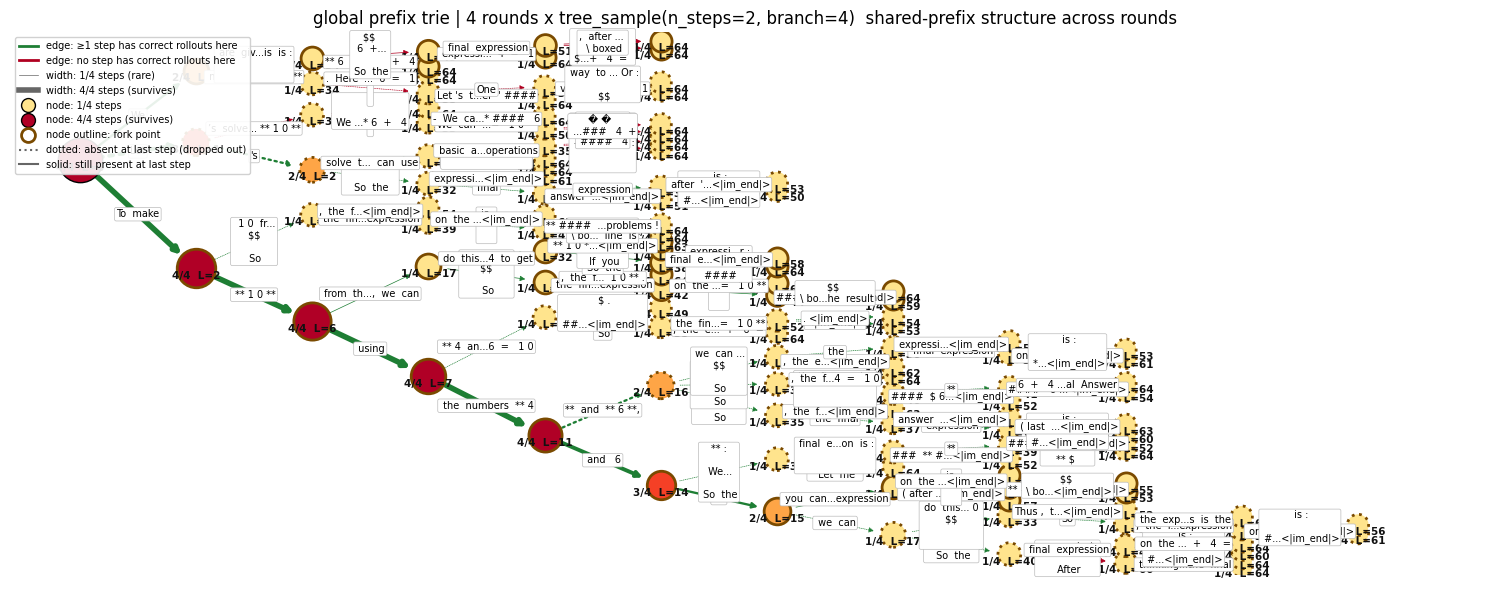

In [24]:
# (gadget-1) "Global" prefix trie pooled from several rollout batches on one query.
#     Reuses tree_sample, so the SAME cell explores the whole sampling-config
#     space: set N_STEPS=1 for flat batches, or N_STEPS>1 / BRANCH>1 to fork and
#     watch the prefix bottleneck collapse diversity. Each round is one tree_sample
#     call; all rounds pool into one persistent pt.MultiStepTrie keyed by round:
#       - node face  -> in how many of the R rounds the prefix recurs (survival)
#       - edge width -> same survival, thin=1 round, thick=all rounds
#       - L=         -> accumulated prefix length (tokens) from root
#     NOTE: tree_sample dedups identical continuations, so the per-round group is
#     the DISTINCT leaves; total intended samples = BRANCH**N_STEPS.

R          = 4      # number of rollout batches ("rounds" / global steps)
N_STEPS    = 2      # tree-sampling depth (1 = flat batch; >1 = forking)
BRANCH     = 4      # continuations per leaf per step
BLOCK_SIZE = 64 // N_STEPS   # per-step extension; total new tokens ~= 64
TEMP       = 1.0

decode_tok = lambda ids: [tokenizer.decode([i]) for i in ids]

global_trie = pt.MultiStepTrie()
for r in range(R):
    _, steps = tree_sample(PROMPT, n_steps=N_STEPS, block_size=BLOCK_SIZE,
                           branch=BRANCH, temperature=TEMP, seed=r)
    final  = steps[max(steps)]                                   # distinct leaf rollouts
    txts   = [tokenizer.decode(ids, skip_special_tokens=True) for ids in final]
    nums   = [NUMBERS] * len(txts)
    fmt    = np.array(g24.format_reward(txts), dtype=float)
    corr   = np.array(g24.correctness_reward(txts, nums, target=TARGET), dtype=float)
    reward = fmt + corr
    adv    = (reward - reward.mean()) / (reward.std() + EPS)      # GRPO group baseline
    for ids, c, a in zip(final, corr, adv):
        global_trie.insert(decode_tok(ids), correct=bool(c), step=r, advantage=float(a))
    print(f"round {r}: solved={int(corr.sum())}/{len(final)}  "
          f"distinct={len(final)}/{BRANCH**N_STEPS} intended")

steps = list(range(R))
fig, ax = plt.subplots(figsize=(15, 6))
pt.draw_overlay_trie(ax, global_trie, steps)
ax.legend(handles=pt.overlay_legend_handles(steps), loc="upper left",
          fontsize=7, framealpha=0.9)
ax.set_title(f"global prefix trie | {R} rounds x tree_sample"
             f"(n_steps={N_STEPS}, branch={BRANCH})  "
             f"shared-prefix structure across rounds")
plt.tight_layout()
plt.show()

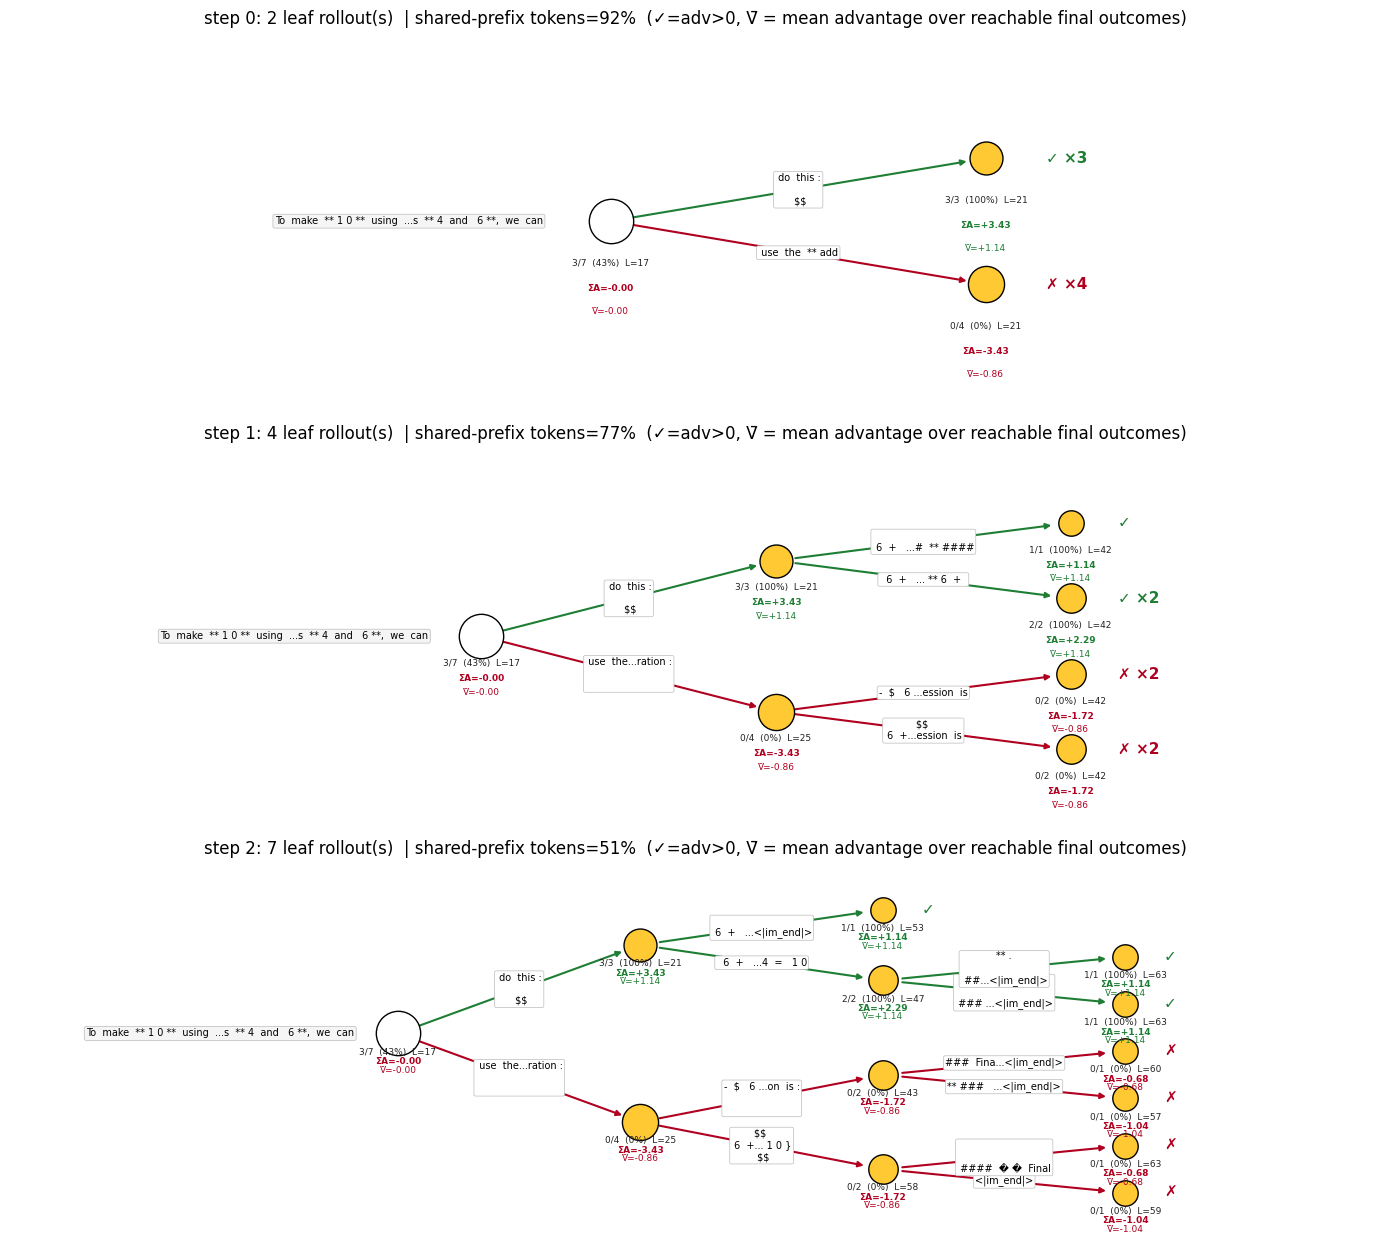

In [20]:
# (3) Visualize the tree after each sampling step (real tokens).

def decode_tokens(ids):
    return [tokenizer.decode([i]) for i in ids]

# advantage carried by each FINAL rollout (token-id tuple -> a_i)
adv_of_final = {tuple(ids): a for ids, a in zip(final, adv.tolist())}

def step_rows(step_leaves):
    """For one sampling step, attach to every leaf-prefix the advantages of all
    FINAL rollouts that extend it. Yields (decoded_tokens, correct, advantage)
    once per (prefix, reachable-final) pair so shared nodes aggregate honest
    ΣA / V̄ over the real downstream outcomes instead of a constant placeholder."""
    rows = []
    for leaf in step_leaves:
        L = len(leaf)
        key = tuple(leaf)
        reach = [a for ids, a in adv_of_final.items() if ids[:L] == key]
        if not reach:                       # leaf already is a final rollout
            reach = [adv_of_final.get(key, 0.0)]
        toks = decode_tokens(leaf)
        for a in reach:
            rows.append((toks, a > 0, a))
    return rows

n_steps = len(steps)
fig, axes = plt.subplots(n_steps, 1, figsize=(14, 4.2 * n_steps))
axes = np.atleast_1d(axes)
for step, ax in zip(sorted(steps), axes):
    vt = pt.Trie()
    for toks, c, a in step_rows(steps[step]):
        vt.insert(toks, correct=c, advantage=a)
    pt.draw_compressed_trie(ax, vt, value_mode="mean")   # honest V̄ = ΣA / n
    ax.set_title(f"step {step}: {len(steps[step])} leaf rollout(s)  | "
                 f"shared-prefix tokens={vt.shared_prefix_token_fraction:.0%}  "
                 f"(✓=adv>0, V̄ = mean advantage over reachable final outcomes)")
plt.tight_layout()
plt.show()


In [ ]:
# [Idea]. On each node, we have a 'prefix confidence' and a 'predictive score', both can be leveraged to prioritize rollout ordering
